## Positional Encoding（正余弦位置编码）逐步可视化

这个 Notebook 复现 `pos.py` 里的计算，并把每一步的张量和值可视化出来，帮助你理解：

- `position`（位置）
- `(2i/d_model)` 与 `(exp_base^(2i/d_model))`
- `div_term = exp(-(log(exp_base)/d_model) * (2i))`
- `position * div_term`（等价于 `position / exp_base^(2i/d_model)`）
- `sin`/`cos` 的变化
- 最终每个 `seq` 位置的编码向量，以及整体热力图

> 说明：`pos.py` 里有 `pdb.set_trace()`，这里不会触发断点，而是直接把所有中间值展开给你看。

In [34]:
import math

import torch
import matplotlib.pyplot as plt

# 为了输出更直观
torch.set_printoptions(precision=6, sci_mode=False)
plt.rcParams["figure.dpi"] = 120

In [35]:
# 你可以自由改这些参数

d_model = 512
max_len = 1024  # 相当于 pos.py 里的 max_len
exp_base = 100.0 # 原来的论文中，写的是10000.0， 但是从后续的可视化效果，如果是10000.0的话，纬度分量在60之后，变化就很小了，即虽然是512维度，但是只有60维以前的分量，针对不同位置有比较明显的表达。
                   # 影响因素2: 位置编码，就是要反应：相邻位置的编码要相似，远距离位置的编码要差异较大。 最后一个实验会反馈，不同exp_base下，位置向量之间的距离
# 位置: [max_len, 1]
position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)
position

tensor([[          0.],
        [          1.],
        [          2.],
        ...,
        [       1021.],
        [       1022.],
        [       1023.]])

### 1) 维度索引 i、(2i/d_model)、以及分母 exp_base^(2i/d_model)

把论文里的常数 `10000` 参数化成 `exp_base` 后：

- 偶数维：\(PE(pos, 2i) = \sin\big(pos / \text{exp\_base}^{2i/d\_model}\big)\)
- 奇数维：\(PE(pos, 2i+1) = \cos\big(pos / \text{exp\_base}^{2i/d\_model}\big)\)

而在 `pos.py` 里，用 `div_term` 把除法改写成了乘法：

\[
\text{div\_term}(i) = \exp\Big(-\frac{\log(\text{exp\_base})}{d\_model} \cdot 2i\Big)
= \text{exp\_base}^{-2i/d\_model}
\]

因此 \(pos / \text{exp\_base}^{2i/d\_model} = pos \cdot \text{div\_term}(i)\)。

直观上：`exp_base` **越大**，同样的 \(i\) 下 `div_term` 越小，`angle=pos*div_term` 增长更慢（波形更“平”）；`exp_base` **越小** 则相反。

In [36]:
i_even = torch.arange(0, d_model, 2, dtype=torch.float32)          # 0,2,4,...
i = i_even / 2                                                    # 真正的 i: 0,1,2,...

ratio = (2 * i) / d_model                                         # 2i/d_model

denom = exp_base ** ratio                                         # exp_base^(2i/d_model)

# 参数化实现：div_term = exp( -(log(exp_base)/d_model) * (0,2,4,...) )
div_term = torch.exp(i_even * -(math.log(exp_base) / d_model))     # == exp_base^(-2i/d_model)

print("exp_base  =", exp_base)
print("i         =", i)
print("2i/d      =", ratio)
print("denom     =", denom)
print("div_term  =", div_term)

# 验证 div_term == 1/denom
print("max|div_term - 1/denom| =", (div_term - 1/denom).abs().max().item())

exp_base  = 100.0
i         = tensor([  0.,   1.,   2.,   3.,   4.,   5.,   6.,   7.,   8.,   9.,  10.,  11.,
         12.,  13.,  14.,  15.,  16.,  17.,  18.,  19.,  20.,  21.,  22.,  23.,
         24.,  25.,  26.,  27.,  28.,  29.,  30.,  31.,  32.,  33.,  34.,  35.,
         36.,  37.,  38.,  39.,  40.,  41.,  42.,  43.,  44.,  45.,  46.,  47.,
         48.,  49.,  50.,  51.,  52.,  53.,  54.,  55.,  56.,  57.,  58.,  59.,
         60.,  61.,  62.,  63.,  64.,  65.,  66.,  67.,  68.,  69.,  70.,  71.,
         72.,  73.,  74.,  75.,  76.,  77.,  78.,  79.,  80.,  81.,  82.,  83.,
         84.,  85.,  86.,  87.,  88.,  89.,  90.,  91.,  92.,  93.,  94.,  95.,
         96.,  97.,  98.,  99., 100., 101., 102., 103., 104., 105., 106., 107.,
        108., 109., 110., 111., 112., 113., 114., 115., 116., 117., 118., 119.,
        120., 121., 122., 123., 124., 125., 126., 127., 128., 129., 130., 131.,
        132., 133., 134., 135., 136., 137., 138., 139., 140., 141., 142., 143.,
        14

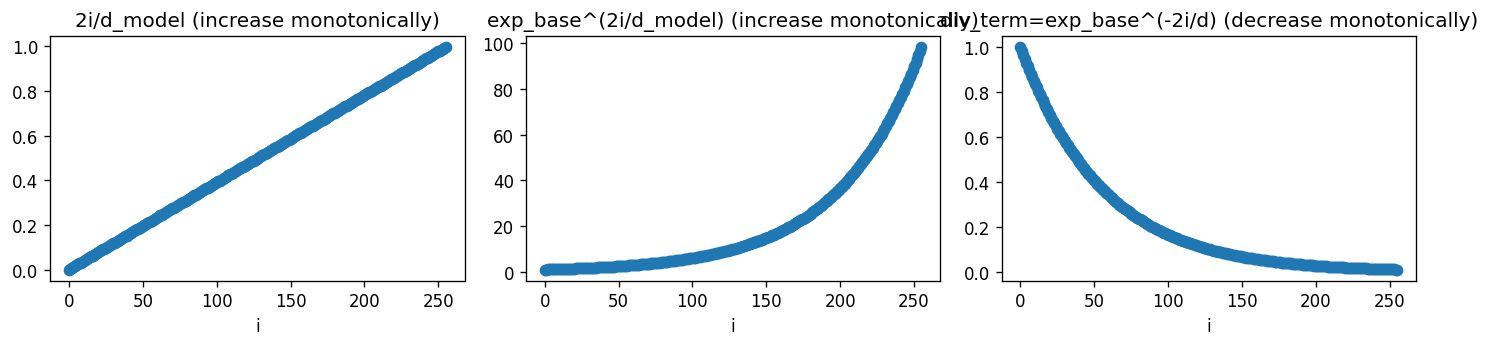

In [37]:
# 单调性：ratio 随 i 增大单调增；denom 单调增；div_term 单调减

fig, ax = plt.subplots(1, 3, figsize=(12, 3))

ax[0].plot(i.numpy(), ratio.numpy(), marker='o')
ax[0].set_title("2i/d_model (increase monotonically)")
ax[0].set_xlabel("i")

ax[1].plot(i.numpy(), denom.numpy(), marker='o')
ax[1].set_title("exp_base^(2i/d_model) (increase monotonically)")
ax[1].set_xlabel("i")

ax[2].plot(i.numpy(), div_term.numpy(), marker='o')
ax[2].set_title("div_term=exp_base^(-2i/d) (decrease monotonically)")
ax[2].set_xlabel("i")

plt.tight_layout()
plt.show()

如上图所示，变化规律是：对于 `d_model` 的不同维度分量，随着 \(i\) 增大，分母 \(\text{exp\_base}^{2i/d\_model}\) 会变得越来越大，从而 \(\text{div\_term}=\text{exp\_base}^{-2i/d\_model}\) 越来越小，导致后续的整个角度 `angle = position * div_term` 变得更小、变化更慢。

### 2) 观察 `position * div_term`：随 i 增大，整体变化更“慢”

因为 `div_term(i)` 随 i 变大而变小，所以对同一个 `position`，`position * div_term(i)` 的数值范围会更小。

直观结果：
- 小 i（比如 i=0，第一个分量）：`div_term` 大，角度增长快，`sin/cos` 随位置变化更快（频率更高）
- 大 i（比如 i 很大，高维度分量）：`div_term` 小，角度增长慢，`sin/cos` 随位置变化更慢（频率更低）

补充：`exp_base` 越大，上述“高维更慢”的趋势会更明显；`exp_base` 越小则相对更平缓。

position.shape = (1024, 1) position = [   0.    1.    2. ... 1021. 1022. 1023.]
div_term.shape = (256,) div_term = [1.      0.98217 0.96466 0.94746 0.93057 0.91398 0.89769 0.88168 0.86596
 0.85053 0.83536 0.82047 0.80584 0.79148 0.77737 0.76351 0.74989 0.73652
 0.72339 0.7105  0.69783 0.68539 0.67317 0.66117 0.64938 0.6378  0.62643
 0.61527 0.6043  0.59352 0.58294 0.57255 0.56234 0.55232 0.54247 0.5328
 0.5233  0.51397 0.50481 0.49581 0.48697 0.47829 0.46976 0.46138 0.45316
 0.44508 0.43714 0.42935 0.4217  0.41418 0.40679 0.39954 0.39242 0.38542
 0.37855 0.3718  0.36517 0.35866 0.35227 0.34599 0.33982 0.33376 0.32781
 0.32197 0.31623 0.31059 0.30505 0.29961 0.29427 0.28903 0.28387 0.27881
 0.27384 0.26896 0.26416 0.25946 0.25483 0.25029 0.24582 0.24144 0.23714
 0.23291 0.22876 0.22468 0.22067 0.21674 0.21288 0.20908 0.20535 0.20169
 0.1981  0.19456 0.1911  0.18769 0.18434 0.18106 0.17783 0.17466 0.17154
 0.16849 0.16548 0.16253 0.15963 0.15679 0.15399 0.15125 0.14855 0.1459
 0.1433  0.

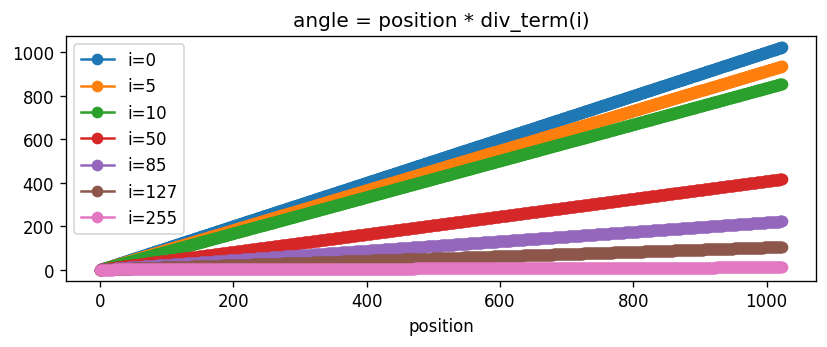


angle(前几行)
 tensor([[0.000000, 0.000000, 0.000000, 0.000000, 0.000000, 0.000000],
        [1.000000, 0.982172, 0.964662, 0.947464, 0.930572, 0.913982],
        [2.000000, 1.964344, 1.929323, 1.894927, 1.861144, 1.827963],
        [3.000000, 2.946516, 2.893985, 2.842391, 2.791716, 2.741945],
        [4.000000, 3.928688, 3.858646, 3.789854, 3.722288, 3.655927],
        [5.000000, 4.910860, 4.823308, 4.737318, 4.652860, 4.569908]])

 


In [38]:
# angle: [max_len, d_model/2]，对应偶数维 (2i)
angle = position * div_term  # broadcast

print("position.shape =", tuple(position.shape), "position =", position.squeeze(1).numpy())
# 我希望打印浮点数，而不是科学计数法
import numpy as np
np.set_printoptions(precision=5, suppress=True)
print("div_term.shape =", tuple(div_term.shape), "div_term =", div_term.numpy())
print("angle.shape    =", tuple(angle.shape))

# 看几个 i 的 angle 随 position 的变化
pick_is = [0, 5, 10, 50,int(i.max().item()/3), int(i.max().item()/2), int(i.max().item())]

fig, ax = plt.subplots(1, 1, figsize=(7, 3))
for pi in pick_is:
    ax.plot(position.squeeze(1).numpy(), angle[:, pi].numpy(), marker='o', label=f"i={pi}")
ax.set_title("angle = position * div_term(i)")
ax.set_xlabel("position")
ax.legend()
plt.tight_layout()
plt.show()

# 打印一个小表格（position x i）帮助对比
print("\nangle(前几行)\n", angle[:min(max_len, 6), :min(angle.shape[1], 6)])
print("\n ")

### 3) 先看 `sin` / `cos` 函数本身（不带位置编码）

`sin`/`cos` **不是全局单调函数**，而是每隔 \(2\pi\) 周期重复；但在某些区间内它们是**分段单调**的。

下面直接画：
- \(y=\sin(x)\)
- \(y=\cos(x)\)
并标出关键点 \(-2\pi,-\pi,0,\pi,2\pi\)。

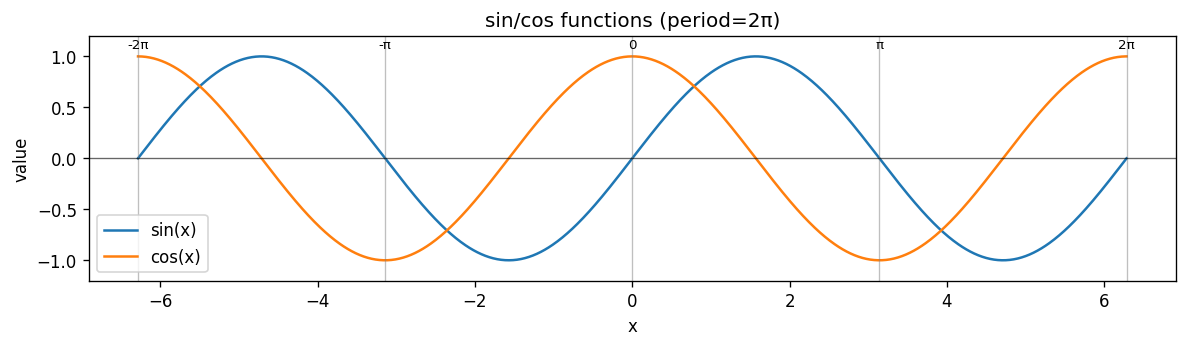

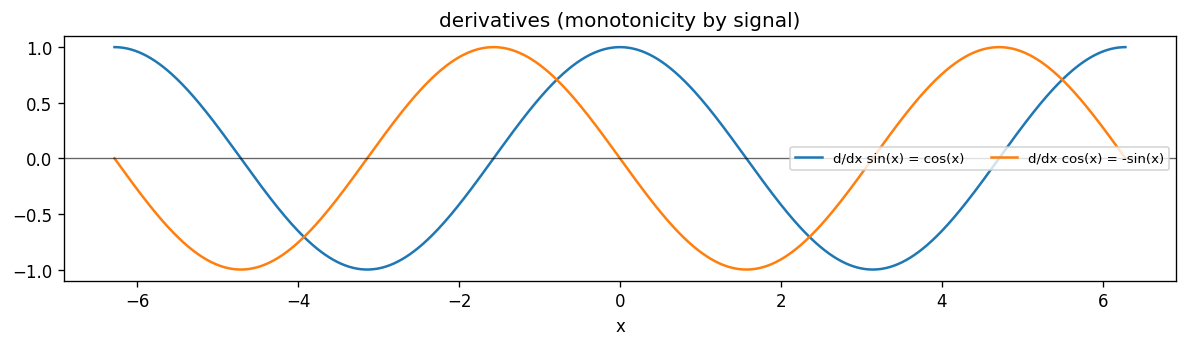

In [39]:
import numpy as np

x = torch.linspace(-2 * math.pi, 2 * math.pi, 1000)

plt.figure(figsize=(10, 3))
plt.plot(x.numpy(), torch.sin(x).numpy(), label="sin(x)")
plt.plot(x.numpy(), torch.cos(x).numpy(), label="cos(x)")

for k, lab in [(-2*math.pi, r"-2π"), (-math.pi, r"-π"), (0, "0"), (math.pi, r"π"), (2*math.pi, r"2π")]:
    plt.axvline(k, color="gray", linewidth=0.8, alpha=0.5)
    plt.text(k, 1.05, lab, ha="center", va="bottom", fontsize=8)

plt.axhline(0, color="black", linewidth=0.8, alpha=0.6)
plt.ylim(-1.2, 1.2)
plt.title("sin/cos functions (period=2π)")
plt.xlabel("x")
plt.ylabel("value")
plt.legend()
plt.tight_layout()
plt.show()

# 额外：看导数（帮助理解单调区间）
# d/dx sin(x)=cos(x), d/dx cos(x)=-sin(x)
plt.figure(figsize=(10, 3))
plt.plot(x.numpy(), torch.cos(x).numpy(), label="d/dx sin(x) = cos(x)")
plt.plot(x.numpy(), (-torch.sin(x)).numpy(), label="d/dx cos(x) = -sin(x)")
plt.axhline(0, color="black", linewidth=0.8, alpha=0.6)
plt.title("derivatives (monotonicity by signal)")
plt.xlabel("x")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### 3) 分别看 `sin(angle)`（偶数维）与 `cos(angle)`（奇数维）

对应 `pos.py`：

- `encoding[:, 0::2] = sin(position * div_term)`
- `encoding[:, 1::2] = cos(position * div_term)`

下面我们直接画出若干个维度（不同 i）随 `position` 的波形。

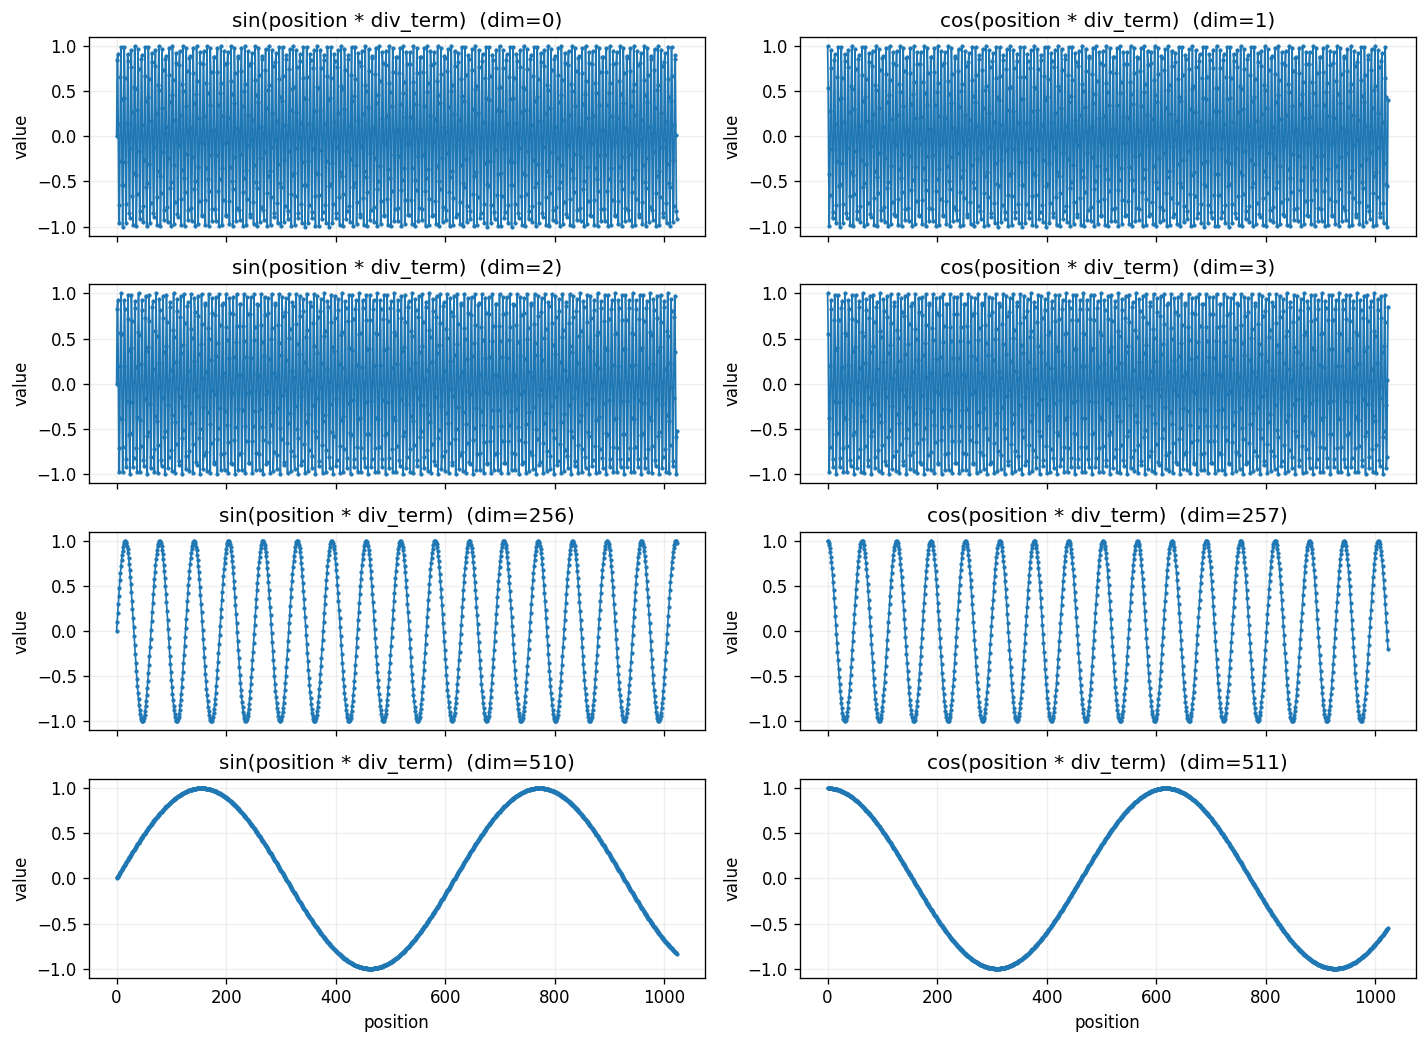

sin_part(前几行)
 tensor([[ 0.000000,  0.000000,  0.000000,  0.000000,  0.000000,  0.000000],
        [ 0.841471,  0.831705,  0.821856,  0.811937,  0.801962,  0.791941],
        [ 0.909297,  0.923555,  0.936415,  0.947928,  0.958144,  0.967114],
        [ 0.141120,  0.193842,  0.245085,  0.294758,  0.342782,  0.389094],
        [-0.756802, -0.708306, -0.657167, -0.603801, -0.548606, -0.491955],
        [-0.958924, -0.980369, -0.993855, -0.999689, -0.998229, -0.989867]])

cos_part(前几行)
 tensor([[ 1.000000,  1.000000,  1.000000,  1.000000,  1.000000,  1.000000],
        [ 0.540302,  0.555217,  0.569695,  0.583744,  0.597375,  0.610597],
        [-0.416147, -0.383467, -0.350895, -0.318485, -0.286285, -0.254342],
        [-0.989992, -0.981033, -0.969501, -0.955572, -0.939415, -0.921198],
        [-0.653644, -0.705906, -0.753745, -0.797135, -0.836081, -0.870620],
        [ 0.283662,  0.197170,  0.110692,  0.024926, -0.059494, -0.141999]])


In [40]:
sin_part = torch.sin(angle)  # [max_len, d_model/2]
cos_part = torch.cos(angle)  # [max_len, d_model/2]

# 选几个 i（也就是对应维度 2i / 2i+1）
pick_is = [0, 1, max(0, sin_part.shape[1] // 2), sin_part.shape[1] - 1]

pos_np = position.squeeze(1).numpy()

# 修改1：不同 i 画在不同子图（每个 i 一行；左 sin / 右 cos）
# 修改2：marker 点更小、更细
n = len(pick_is)
fig, axes = plt.subplots(nrows=n, ncols=2, figsize=(12, 2.2 * n), sharex=True)

# 兼容 n=1 的情况
if n == 1:
    axes = np.array([axes])

for r, pi in enumerate(pick_is):
    ax_sin = axes[r, 0]
    ax_cos = axes[r, 1]

    ax_sin.plot(
        pos_np,
        sin_part[:, pi].numpy(),
        marker="o",
        markersize=2,
        linewidth=1,
        markeredgewidth=0.5,
        label=f"sin dim=2*{pi}",
    )
    ax_sin.set_title(f"sin(position * div_term)  (dim={2*pi})")
    ax_sin.set_ylabel("value")
    ax_sin.grid(alpha=0.2)

    ax_cos.plot(
        pos_np,
        cos_part[:, pi].numpy(),
        marker="o",
        markersize=2,
        linewidth=1,
        markeredgewidth=0.5,
        label=f"cos dim=2*{pi}+1",
    )
    ax_cos.set_title(f"cos(position * div_term)  (dim={2*pi+1})")
    ax_cos.set_ylabel("value")
    ax_cos.grid(alpha=0.2)

    # 如果你想保留图例，可打开下面两行
    # ax_sin.legend(fontsize=8)
    # ax_cos.legend(fontsize=8)

axes[-1, 0].set_xlabel("position")
axes[-1, 1].set_xlabel("position")

plt.tight_layout()
plt.show()

print("sin_part(前几行)\n", sin_part[: min(max_len, 6), : min(sin_part.shape[1], 6)])
print("\ncos_part(前几行)\n", cos_part[: min(max_len, 6), : min(cos_part.shape[1], 6)])

### 4) 组装最终 `encoding[max_len, d_model]` 并画热力图

这一步完全对齐 `pos.py` 的写法：

- `encoding[:, 0::2] = sin_part`
- `encoding[:, 1::2] = cos_part`

然后我们画：
- 整体热力图（位置 vs 维度）
- 每个 position 的向量（你可以点选某个位置看数值）

encoding.shape = (1024, 512)
encoding[0] (position=0)
 tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0

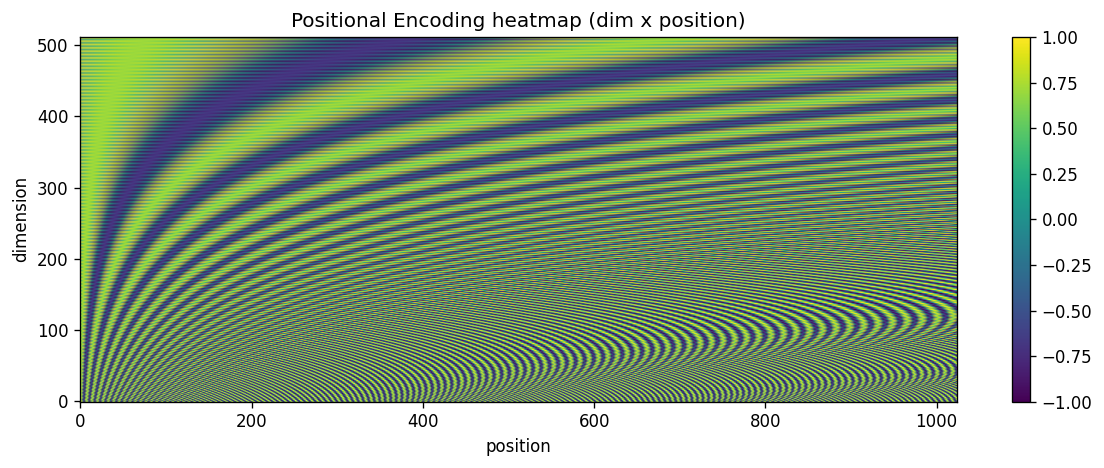

In [41]:
encoding = torch.zeros(max_len, d_model, dtype=torch.float32)
encoding[:, 0::2] = sin_part
encoding[:, 1::2] = cos_part

print("encoding.shape =", tuple(encoding.shape))
print("encoding[0] (position=0)\n", encoding[0])

plt.figure(figsize=(10, 4))
plt.imshow(encoding.numpy().T, aspect='auto', origin='lower')
plt.colorbar()
plt.title("Positional Encoding heatmap (dim x position)")
plt.xlabel("position")
plt.ylabel("dimension")
plt.tight_layout()
plt.show()

In [42]:
# 查看某个 position 的编码向量（逐位置）

pos_to_view = 0  # 改成 1,2,...
print(f"encoding[position={pos_to_view}] =\n", encoding[pos_to_view])

# 也可以把所有 position 的前几维拼成表
print("\nencoding[:5, :12]\n", encoding[:min(5, max_len), :min(12, d_model)])

encoding[position=0] =
 tensor([0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1., 0., 1.,
        0., 1., 

### 5) 进一步的“单调性”理解（关键点）

- **`2i/d_model` 随 i 单调递增**。
- 因此 **`exp_base^(2i/d_model)` 随 i 单调递增**。
- 所以 **`div_term = exp_base^(-2i/d_model)` 随 i 单调递减**。
- 对固定 `position`，`angle = position * div_term(i)` 也随 i 递减（因为乘了更小的 `div_term`）。
- `sin/cos` 本身不是单调函数，但它们的“变化速度/频率”会随 `i` 变大而变慢：i 越大，`angle` 增长越慢，波形越“平”。

补充：`exp_base` 越大，`div_term` 随 i 衰减得越快（同样的 i 下值更小），从而更快进入“高维变化非常慢”的状态。

如果你想更清楚地看“频率差异”，把 `max_len` 调大（比如 200、500）会更明显。

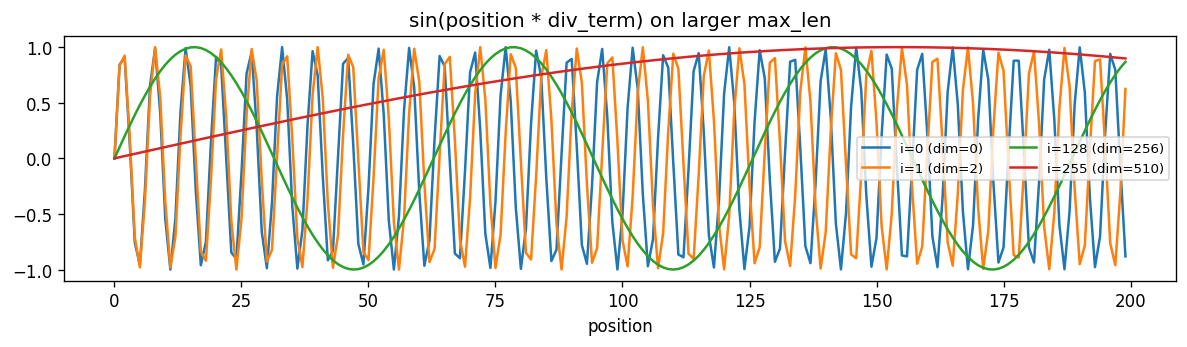

In [43]:
# 可选：把 max_len 调大，直观看不同 i 的“频率/变化快慢”

max_len_big = 200
position_big = torch.arange(0, max_len_big, dtype=torch.float32).unsqueeze(1)
angle_big = position_big * div_term

sin_big = torch.sin(angle_big)

pick_is = [0, 1, sin_big.shape[1]//2, sin_big.shape[1]-1]

plt.figure(figsize=(10, 3))
for pi in pick_is:
    plt.plot(position_big.squeeze(1).numpy(), sin_big[:, pi].numpy(), label=f"i={pi} (dim={2*pi})")
plt.title("sin(position * div_term) on larger max_len")
plt.xlabel("position")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()

### 6) 可视化实验：不同 `exp_base` 下，`PE(0)` 与 `PE(p)` 的余弦距离曲线（p ∈ [0, 10000]）

目标：比较 `exp_base ∈ {10, 100, 1000, 10000}` 时，位置编码随 `position` 拉开/变化的幅度。

我们用 **余弦距离**来衡量：

\[
\text{cos\_dist}(a,b) = 1 - \frac{a\cdot b}{\|a\|\,\|b\|}
\]

做法：

- 取 `p = 0..10000`（可通过 `step` 降采样）
- 对每个 `exp_base` **一次性生成完整的 `encoding[p, d_model]`**
- 再计算整条曲线：对每个 `p`，求 `cos_dist(encoding[p], encoding[0])`

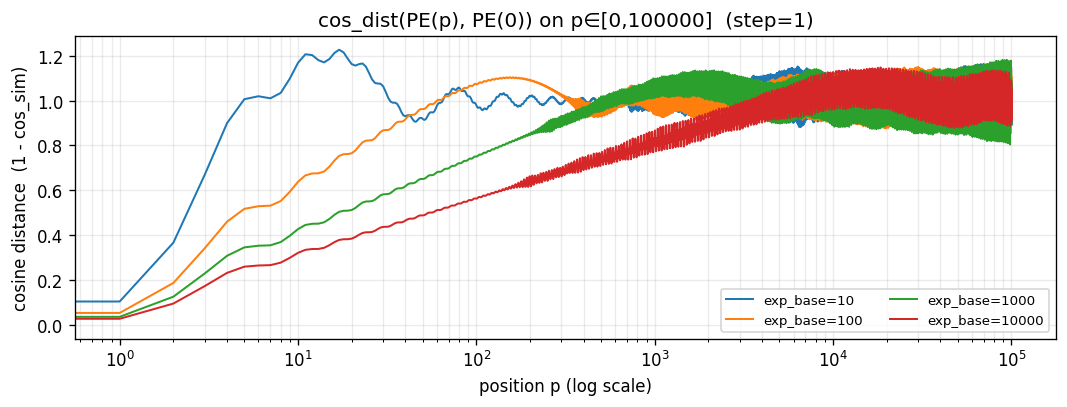

In [44]:
import numpy as np


exp_bases = [10.0, 100.0, 1000.0, 10000.0]

# p ∈ [0, 10000]
max_pos = 100000
step = 1  # 若你觉得点太多，可以改成 2/5/10
positions = torch.arange(0, max_pos + 1, step, dtype=torch.float32)  # [N]


def build_positional_encoding(max_len: int, d_model: int, exp_base: float) -> torch.Tensor:
    """生成完整位置编码矩阵: [max_len, d_model]."""
    encoding = torch.zeros(max_len, d_model, dtype=torch.float32)

    position = torch.arange(0, max_len, dtype=torch.float32).unsqueeze(1)  # [max_len, 1]
    i_even = torch.arange(0, d_model, 2, dtype=torch.float32)              # [d_model/2]
    div_term = torch.exp(i_even * -(math.log(exp_base) / d_model))          # [d_model/2]

    angle = position * div_term  # [max_len, d_model/2]
    encoding[:, 0::2] = torch.sin(angle)
    encoding[:, 1::2] = torch.cos(angle)
    return encoding


def cosine_distance_to_first_row(encoding: torch.Tensor, eps: float = 1e-12) -> np.ndarray:
    """对每一行计算 cos_dist(row, encoding[0]). 返回 shape [max_len]."""
    e = encoding
    e0 = e[0]

    e_norm = e / (e.norm(dim=1, keepdim=True) + eps)      # [N, d]
    e0_norm = e0 / (e0.norm(p=2) + eps)                   # [d]

    cos_sim = (e_norm * e0_norm).sum(dim=1)               # [N]
    cos_dist = 1.0 - cos_sim
    return cos_dist.cpu().numpy()


curves = {}
x = positions.cpu().numpy()  # [N]

# 一次性生成 encoding，再计算与 pos0 的余弦距离
for b in exp_bases:
    enc = build_positional_encoding(max_pos + 1, d_model, b)   # [10001, d_model]
    curves[b] = cosine_distance_to_first_row(enc)

plt.figure(figsize=(9, 3.5))
for b in exp_bases:
    plt.plot(x, curves[b], linewidth=1.2, label=f"exp_base={b:g}")

plt.xscale("log")
plt.xlabel("position p (log scale)")
plt.ylabel("cosine distance  (1 - cos_sim)")
plt.title(f"cos_dist(PE(p), PE(0)) on p∈[0,{max_pos}]  (step={step})")
plt.grid(alpha=0.25, which="both")
plt.legend(ncol=2, fontsize=8)
plt.tight_layout()
plt.show()